# Cicero exact dialogue input visibility

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 17
## CICERO exact dialogue-input matched-text visibility audit

Notebook 16 established that the released CICERO planner is a clean mechanistic intent reference: generated messages could be paired to recipient-specific bilateral planner results, and submitted orders were on-support under the cached search policy.

Notebook 17 asks the next, stricter question:

> **Is the planner's action identity actually privileged relative to the text seen by CICERO's dialogue model, or is the relevant strategic intent already serialized into the dialogue model's own input?**

The released CICERO dialogue task is trained on a formatter that includes message history, board state, and **pseudo-orders**. Notebook 16's runtime log already shows a first concrete example in which the dialogue-model sequence contains current and rollout pseudo-orders before the outward message is generated. This notebook instruments that exact wrapper boundary for a measured set of messages.

### Primary matched-text comparison

For each accepted outward message:

1. capture the **exact input sequence** passed into the generative dialogue model;
2. identify the exact model-generation call whose output produced the final accepted message;
3. pair that input to the most recent preceding bilateral planner result with matching **sender + recipient + phase**;
4. deterministically extract the sender's current-phase pseudo-order block from the exact model input;
5. compare that text-only extraction with the internal planner's top action for the sender.

The primary metric is the exact order-set match rate:

`exact_input_pseudoorder_observer == planner_agent_policy_top_action`.

A secondary raw-visibility metric asks whether every normalized order in the planner top action appears anywhere in the exact dialogue input.

### Claim boundary

This is a **mechanistic matched-information audit**, not the project's original activation-vs-text H1 test. CICERO's explicit planner object is not a neural activation reader. If the planner action is already present in the dialogue-model input as pseudo-orders, that is a scientifically useful calibration result: the planner remains a mechanistic cause/reference for dialogue, but its action identity is **not privileged information relative to an exact-input text observer**.

No generative auditor is weakened or substituted after seeing outcomes. A deterministic parser is deliberately the strongest appropriate control when the target is literally encoded in a structured portion of the supplied text.

### Frozen upstream handoff

The default accepted Notebook 16 run is pinned to:

`20260815T143203Z`

Override it only intentionally with `LR_NB16_RUN_ID`.


In [1]:
from __future__ import annotations

import hashlib
import importlib.util
import json
import math
import os
import queue
import re
import shlex
import shutil
import signal
import subprocess
import sys
import threading
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

required = {
    "numpy": "numpy<2",
    "pandas": "pandas>=2,<3",
    "matplotlib": "matplotlib>=3.8,<4",
    "tqdm": "tqdm>=4.66",
}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

NOTEBOOK_BUILD = "latent-reservations-notebook17-cicero-exact-dialogue-visibility-v1"
print("=" * 100)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("CICERO exact dialogue-input matched-text visibility audit")
print("=" * 100)


NOTEBOOK BUILD: latent-reservations-notebook17-cicero-exact-dialogue-visibility-v1
CICERO exact dialogue-input matched-text visibility audit


## 1. Paths, frozen handoff, and run controls

The notebook uses the same isolated Python 3.7 / PyTorch 1.7.1 runtime validated in Notebooks 14–16. It never edits the frozen CICERO checkout. Runtime monkey-patches live only in this run directory and are loaded through `sitecustomize.py`.


In [2]:
PROJECT_ROOT = Path(os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")).expanduser().resolve()
CICERO_REPO = PROJECT_ROOT / "vendor" / "diplomacy_cicero"
CICERO_COMMIT = "e85afeddb34f5b7c1ea0827203b425a0f7e68ead"

LEGACY_ENV = PROJECT_ROOT / ".venvs" / "cicero_full_agent_py37_source_v5"
LEGACY_PYTHON = LEGACY_ENV / "bin" / "python"
PYTHON_BASE = PROJECT_ROOT / "vendor" / "cicero_runtime_v5" / "cpython-3.7.17"
OPENSSL_PREFIX = PROJECT_ROOT / "vendor" / "cicero_runtime_v5" / "openssl-1.1.1w"
COMPARE_CONFIG = CICERO_REPO / "conf" / "c01_ag_cmp" / "cmp.prototxt"
CICERO_AGENT_INCLUDE = "agents/cicero.prototxt"

NB16_RUN_ID = os.environ.get("LR_NB16_RUN_ID", "20260815T143203Z")
NB16_RUN_DIR = (
    PROJECT_ROOT
    / "notebook_outputs"
    / "16_cicero_planner_intent_behavior_measurement"
    / NB16_RUN_ID
)
NB16_SUMMARY_PATH = NB16_RUN_DIR / "results" / "tables" / "result_summary.json"
NB16_LOG_PATH = NB16_RUN_DIR / "data" / "runtime" / "full_agent_measurement.log"

NOTEBOOK_SLUG = "17_cicero_exact_dialogue_input_visibility"
RUN_ID = os.environ.get("LR_RUN_ID", datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"))
BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_DIR = BASE / RUN_ID
MANIFEST_DIR = RUN_DIR / "manifests"
DATA_DIR = RUN_DIR / "data"
RUNTIME_DIR = DATA_DIR / "runtime"
CAPTURE_DIR = DATA_DIR / "exact_dialogue_events"
INSTRUMENT_DIR = DATA_DIR / "instrumentation"
EXACT_INPUT_DIR = DATA_DIR / "exact_dialogue_inputs"
RESULT_DIR = RUN_DIR / "results"
TABLE_DIR = RESULT_DIR / "tables"
FIGURE_DIR = RESULT_DIR / "figures"

for p in [
    MANIFEST_DIR,
    RUNTIME_DIR,
    CAPTURE_DIR,
    INSTRUMENT_DIR,
    EXACT_INPUT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)
BASE.mkdir(parents=True, exist_ok=True)

TARGET_MESSAGE_EPISODES = int(os.environ.get("LR_NB17_TARGET_MESSAGE_EPISODES", "24"))
CAPTURE_TIMEOUT_SECONDS = int(os.environ.get("LR_NB17_CAPTURE_TIMEOUT_SECONDS", "2700"))
STRICT_READINESS = os.environ.get("LR_NB17_STRICT_READINESS", "1").strip().lower() not in {"0", "false", "no"}
EXTRA_COMPARE_OVERRIDES = shlex.split(os.environ.get("LR_NB17_COMPARE_OVERRIDES", ""))
TEXT_VISIBLE_THRESHOLD = float(os.environ.get("LR_NB17_TEXT_VISIBLE_THRESHOLD", "0.80"))
PRIMARY_OUTPUT_MATCH_THRESHOLD = float(os.environ.get("LR_NB17_OUTPUT_MATCH_THRESHOLD", "0.80"))

(BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(json.dumps({
    "run_id": RUN_ID,
    "run_dir": str(RUN_DIR),
    "nb16_run_id": NB16_RUN_ID,
    "target_message_episodes": TARGET_MESSAGE_EPISODES,
    "capture_timeout_seconds": CAPTURE_TIMEOUT_SECONDS,
    "text_visible_threshold": TEXT_VISIBLE_THRESHOLD,
    "extra_compare_overrides": EXTRA_COMPARE_OVERRIDES,
}, indent=2))


{
  "run_id": "20260815T154340Z",
  "run_dir": "/workspace/latent-reservations/notebook_outputs/17_cicero_exact_dialogue_input_visibility/20260815T154340Z",
  "nb16_run_id": "20260815T143203Z",
  "target_message_episodes": 24,
  "capture_timeout_seconds": 2700,
  "text_visible_threshold": 0.8,
  "extra_compare_overrides": []
}


## 2. Validate Notebook 16 and freeze the dialogue task identity

Notebook 17 will not silently use the newest folder. The accepted Notebook 16 result must explicitly say it is ready for the exact-input observer stage and that no fatal capture error remains.

The previous full-agent log is also used to freeze the actual released generative dialogue task string before this notebook observes any new outcomes.


In [3]:
def capture_command(command, *, cwd=None, env=None, timeout=None):
    completed = subprocess.run(
        [str(x) for x in command],
        cwd=str(cwd) if cwd is not None else None,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        timeout=timeout,
    )
    return {"returncode": completed.returncode, "output": completed.stdout}

required_paths = [
    CICERO_REPO,
    LEGACY_PYTHON,
    PYTHON_BASE,
    COMPARE_CONFIG,
    NB16_SUMMARY_PATH,
    NB16_LOG_PATH,
]
missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError("Missing Notebook 17 prerequisites:\n" + "\n".join(missing_paths))

actual_commit = capture_command(["git", "rev-parse", "HEAD"], cwd=CICERO_REPO)
if actual_commit["returncode"] != 0:
    raise RuntimeError(actual_commit["output"])
actual_commit_value = actual_commit["output"].strip()
if actual_commit_value != CICERO_COMMIT:
    raise RuntimeError(f"Frozen CICERO commit mismatch: {actual_commit_value} != {CICERO_COMMIT}")

tracked_status = capture_command(
    ["git", "status", "--porcelain", "--untracked-files=no"],
    cwd=CICERO_REPO,
)
if tracked_status["returncode"] != 0:
    raise RuntimeError(tracked_status["output"])
if tracked_status["output"].strip():
    raise RuntimeError(
        "Frozen CICERO checkout has tracked modifications. Notebook 17 will not run on an unrecorded source tree:\n"
        + tracked_status["output"]
    )

nb16_summary = json.loads(NB16_SUMMARY_PATH.read_text())
nb16_readiness = nb16_summary.get("readiness", {})
if nb16_summary.get("cicero_commit") != CICERO_COMMIT:
    raise RuntimeError("Notebook 16 CICERO commit does not match Notebook 17 frozen commit.")
if nb16_readiness.get("ready_for_notebook17_exact_dialogue_observer") is not True:
    raise RuntimeError("Notebook 16 is not green for the exact-dialogue observer handoff.")
if nb16_readiness.get("fatal_capture_error_events_absent") is not True:
    raise RuntimeError("Notebook 16 contains a fatal capture error; do not continue.")

nb16_log_text = NB16_LOG_PATH.read_text(encoding="utf-8", errors="replace")
task_matches = re.findall(
    r"Loading dialogue wrapper for model trained on task:\s*([^\n\r]+)",
    nb16_log_text,
)
if not task_matches:
    raise RuntimeError(
        "Could not recover the released generative dialogue task string from the accepted Notebook 16 log."
    )
EXPECTED_DIALOGUE_TASK = task_matches[0].strip()
if "dialogue" not in EXPECTED_DIALOGUE_TASK.lower() or "discriminator" in EXPECTED_DIALOGUE_TASK.lower():
    raise RuntimeError(f"Recovered task does not look like the generative dialogue task: {EXPECTED_DIALOGUE_TASK}")

handoff = {
    "cicero_commit": CICERO_COMMIT,
    "notebook16_run_id": NB16_RUN_ID,
    "notebook16_ready": True,
    "notebook16_fatal_capture_error_events_absent": True,
    "expected_dialogue_task": EXPECTED_DIALOGUE_TASK,
    "dialogue_task_source": str(NB16_LOG_PATH),
}
(TABLE_DIR / "handoff.json").write_text(json.dumps(handoff, indent=2))
print(json.dumps(handoff, indent=2))


{
  "cicero_commit": "e85afeddb34f5b7c1ea0827203b425a0f7e68ead",
  "notebook16_run_id": "20260815T143203Z",
  "notebook16_ready": true,
  "notebook16_fatal_capture_error_events_absent": true,
  "expected_dialogue_task": "message_history_orderhistorysincelastmovementphase_shortstate_pseudoorder_dialogue_chunk",
  "dialogue_task_source": "/workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/data/runtime/full_agent_measurement.log"
}


## 3. Legacy runtime preflight and exact wrapper signatures

The exact-input boundary is `parlai_diplomacy.wrappers.base_wrapper.BaseWrapper.get_model_pred(...)` / `get_model_pred_many(...)`. The released ParlAI Diplomacy wrappers are responsible for converting structured game information into the exact sequence given to the Transformer. This cell verifies those methods in the frozen Python 3.7 runtime before generating the monkey-patch.


In [4]:
stack_markers = sorted(LEGACY_ENV.glob(".latent_reservations_cicero_stack_v5_*"))
if not stack_markers:
    raise RuntimeError("Notebook 14–16 legacy stack marker is missing.")

torch_route_probe = capture_command([
    LEGACY_PYTHON,
    "-c",
    (
        "import json,pathlib,torch; "
        "root=pathlib.Path(torch.__file__).resolve().parent; "
        "print(json.dumps({'version':torch.__version__,'cuda':torch.version.cuda,"
        "'cuda_available':torch.cuda.is_available(),'root':str(root),'lib':str(root/'lib')}))"
    ),
], cwd=CICERO_REPO)
if torch_route_probe["returncode"] != 0:
    raise RuntimeError(torch_route_probe["output"])
torch_route = json.loads(torch_route_probe["output"].strip().splitlines()[-1])
if not torch_route["version"].startswith("1.7.1"):
    raise RuntimeError("Expected PyTorch 1.7.1 in CICERO legacy runtime: " + json.dumps(torch_route))

legacy_runtime_env = os.environ.copy()
legacy_runtime_env.pop("PYTHONHOME", None)
legacy_runtime_env.pop("PYTHONPATH", None)
legacy_runtime_env["PYTHONNOUSERSITE"] = "1"
legacy_runtime_env["VIRTUAL_ENV"] = str(LEGACY_ENV)
legacy_runtime_env["PATH"] = os.pathsep.join([str(LEGACY_ENV / "bin"), os.environ.get("PATH", "")])

runtime_library_dirs = [Path(torch_route["lib"]), LEGACY_ENV / "lib", PYTHON_BASE / "lib"]
for candidate in [OPENSSL_PREFIX / "lib", OPENSSL_PREFIX / "lib64", Path("/usr/local/cuda/lib64")]:
    if candidate.exists():
        runtime_library_dirs.append(candidate)
legacy_runtime_env["LD_LIBRARY_PATH"] = os.pathsep.join(
    str(p) for p in runtime_library_dirs if p.exists()
)

preflight_probe = capture_command([
    LEGACY_PYTHON,
    "-c",
    (
        "import inspect,json,sys,torch,postman; "
        "from fairdiplomacy import pydipcc; "
        "from fairdiplomacy.agents.bqre1p_agent import BQRE1PAgent; "
        "from parlai_diplomacy.wrappers.base_wrapper import BaseWrapper; "
        "print(json.dumps({'python':sys.executable,'torch':torch.__version__,"
        "'cuda_build':torch.version.cuda,'cuda_available':torch.cuda.is_available(),"
        "'postman':postman.__file__,'pydipcc':pydipcc.__file__,"
        "'agent':str(BQRE1PAgent),'base_wrapper':str(BaseWrapper),"
        "'get_model_pred':str(inspect.signature(BaseWrapper.get_model_pred)),"
        "'get_model_pred_many':str(inspect.signature(BaseWrapper.get_model_pred_many))}))"
    ),
], cwd=CICERO_REPO, env=legacy_runtime_env)
(RUNTIME_DIR / "preflight_probe.txt").write_text(preflight_probe["output"])
if preflight_probe["returncode"] != 0:
    raise RuntimeError("Notebook 17 legacy runtime preflight failed:\n" + preflight_probe["output"])
preflight = json.loads(preflight_probe["output"].strip().splitlines()[-1])
print(json.dumps(preflight, indent=2))


{
  "python": "/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python",
  "torch": "1.7.1+cu110",
  "cuda_build": "11.0",
  "cuda_available": true,
  "postman": "/workspace/latent-reservations/vendor/diplomacy_cicero/thirdparty/github/fairinternal/postman/postman/python/postman/__init__.py",
  "pydipcc": "/workspace/latent-reservations/vendor/diplomacy_cicero/fairdiplomacy/pydipcc.cpython-37m-x86_64-linux-gnu.so",
  "agent": "<class 'fairdiplomacy.agents.bqre1p_agent.BQRE1PAgent'>",
  "base_wrapper": "<class 'parlai_diplomacy.wrappers.base_wrapper.BaseWrapper'>",
  "get_model_pred": "(self, input_seq: str, candidates: Union[List[str], NoneType] = None, prefix_str: Union[str, NoneType] = None) -> Dict[str, Any]",
  "get_model_pred_many": "(self, input_seq: str, num_preds: int, batch_size: Union[int, NoneType] = None, prefix_str: Union[str, NoneType] = None) -> List[Tuple[str, float]]"
}


## 4. Generate runtime instrumentation

The instrumentation is deliberately narrow:

- patch the recipient-specific bilateral planner result;
- patch `BQRE1PAgent.generate_message` to establish an outer call identity;
- while that call is active, capture only `BaseWrapper` model calls whose task matches the **frozen generative dialogue task** from Notebook 16;
- record the exact input string **before** model inference and the wrapper return value after inference;
- never record discriminator/order-model inputs as the primary observer text.

The frozen CICERO source tree is untouched.


In [5]:
SITE_CUSTOMIZE_SOURCE = '\nimport hashlib\nimport inspect\nimport json\nimport os\nimport threading\nimport time\nimport traceback\nfrom pathlib import Path\n\n_CAPTURE_DIR_TEXT = os.environ.get("LR_CICERO_CAPTURE_DIR", "").strip()\n_EXPECTED_DIALOGUE_TASK = os.environ.get("LR_NB17_EXPECTED_DIALOGUE_TASK", "").strip()\n\nif _CAPTURE_DIR_TEXT:\n    import numpy as np\n    import torch\n    from fairdiplomacy.agents.bqre1p_agent import BQRE1PAgent\n    from parlai_diplomacy.wrappers.base_wrapper import BaseWrapper\n\n    _CAPTURE_DIR = Path(_CAPTURE_DIR_TEXT)\n    _CAPTURE_DIR.mkdir(parents=True, exist_ok=True)\n    _CAPTURE_PATH = _CAPTURE_DIR / (str(os.getpid()) + ".jsonl")\n    _SEQ = 0\n    _CALL_SEQ = 0\n    _TLS = threading.local()\n    _MAX_SEQUENCE = 512\n    _MAX_POLICY_ACTIONS = 64\n    _MAX_TENSOR_ELEMENTS = 128\n    _MAX_STRING = 40000\n\n    def _next_call_id(prefix):\n        global _CALL_SEQ\n        _CALL_SEQ += 1\n        return prefix + "-" + str(os.getpid()) + "-" + str(_CALL_SEQ)\n\n    def _phase_name(game):\n        try:\n            value = getattr(game, "current_short_phase", None)\n            if callable(value):\n                value = value()\n            return None if value is None else str(value)\n        except Exception:\n            return None\n\n    def _safe(value, depth=0):\n        if depth > 10:\n            return {"__type__": type(value).__module__ + "." + type(value).__name__, "__repr__": repr(value)[:1000]}\n        if value is None or isinstance(value, (bool, int, float)):\n            return value\n        if isinstance(value, str):\n            if len(value) <= _MAX_STRING:\n                return value\n            return value[:_MAX_STRING] + "<LR_TRUNCATED_" + str(len(value) - _MAX_STRING) + ">"\n        if isinstance(value, Path):\n            return str(value)\n        if isinstance(value, torch.Tensor):\n            tensor = value.detach().cpu()\n            payload = {"__type__": "torch.Tensor", "shape": list(tensor.shape), "dtype": str(tensor.dtype), "numel": int(tensor.numel())}\n            if tensor.numel() <= _MAX_TENSOR_ELEMENTS:\n                payload["values"] = tensor.tolist()\n            return payload\n        if isinstance(value, np.ndarray):\n            payload = {"__type__": "numpy.ndarray", "shape": list(value.shape), "dtype": str(value.dtype), "size": int(value.size)}\n            if value.size <= _MAX_TENSOR_ELEMENTS:\n                payload["values"] = value.tolist()\n            return payload\n        if isinstance(value, dict):\n            out = {}\n            items = list(value.items())\n            for key, item in items[:_MAX_SEQUENCE]:\n                out[str(key)] = _safe(item, depth + 1)\n            if len(items) > _MAX_SEQUENCE:\n                out["__truncated_items__"] = len(items) - _MAX_SEQUENCE\n            return out\n        if isinstance(value, (list, tuple, set)):\n            seq = list(value)\n            out = [_safe(item, depth + 1) for item in seq[:_MAX_SEQUENCE]]\n            if len(seq) > _MAX_SEQUENCE:\n                out.append({"__truncated_items__": len(seq) - _MAX_SEQUENCE})\n            return out\n        return {"__type__": type(value).__module__ + "." + type(value).__name__, "__repr__": repr(value)[:2000]}\n\n    def _emit(event, payload):\n        global _SEQ\n        _SEQ += 1\n        record = {\n            "schema_version": 1,\n            "event": event,\n            "sequence": _SEQ,\n            "time_unix": time.time(),\n            "pid": os.getpid(),\n            "ppid": os.getppid(),\n            "thread_id": threading.current_thread().ident,\n            "payload": _safe(payload),\n        }\n        encoded = json.dumps(record, separators=(",", ":"), sort_keys=True)\n        with _CAPTURE_PATH.open("a", encoding="utf-8") as handle:\n            handle.write(encoded)\n            handle.write("\\n")\n            handle.flush()\n            os.fsync(handle.fileno())\n\n    def _action_orders(action):\n        if action is None:\n            return []\n        if isinstance(action, (tuple, list)):\n            return [str(x) for x in action]\n        if isinstance(action, str):\n            if " | " in action:\n                return [part.strip() for part in action.split(" | ") if part.strip()]\n            return [action]\n        return [str(action)]\n\n    def _policy_payload(policy):\n        if not isinstance(policy, dict):\n            return {"__error__": "policy_not_dict", "value": _safe(policy)}\n        powers = {}\n        for power, dist in policy.items():\n            if not isinstance(dist, dict):\n                continue\n            rows = []\n            for action, probability in dist.items():\n                try:\n                    prob = float(probability)\n                except Exception:\n                    continue\n                rows.append({"orders": _action_orders(action), "probability": prob})\n            rows.sort(key=lambda row: -row["probability"])\n            powers[str(power)] = {\n                "action_count": len(rows),\n                "actions": rows[:_MAX_POLICY_ACTIONS],\n                "truncated_actions": max(0, len(rows) - _MAX_POLICY_ACTIONS),\n            }\n        return powers\n\n    def _planner_payload(result):\n        payload = {\n            "type": type(result).__module__ + "." + type(result).__name__,\n            "policies": {},\n        }\n        for name in ["get_agent_policy", "get_bp_policy"]:\n            method = getattr(result, name, None)\n            if method is None or not callable(method):\n                payload["policies"][name] = {"__missing__": True}\n                continue\n            try:\n                payload["policies"][name] = _policy_payload(method())\n            except Exception as exc:\n                payload["policies"][name] = {"__error__": repr(exc)}\n        return payload\n\n    def _bound_inputs(original, instance, args, kwargs):\n        raw = {}\n        try:\n            signature = inspect.signature(original)\n            bound = signature.bind_partial(instance, *args, **kwargs)\n            raw = dict(bound.arguments)\n            raw.pop("self", None)\n        except Exception:\n            pass\n        payload = {}\n        game = raw.get("game")\n        if game is not None:\n            payload["phase"] = _phase_name(game)\n            try:\n                raw_json = game.to_json()\n                if not isinstance(raw_json, str):\n                    raw_json = json.dumps(raw_json, sort_keys=True)\n                payload["game_json_sha256"] = hashlib.sha256(raw_json.encode("utf-8", "replace")).hexdigest()\n            except Exception:\n                pass\n        for name in ["power", "agent_power", "other_power", "recipient", "timestamp"]:\n            if name in raw:\n                payload[name] = _safe(raw[name])\n        return payload, raw\n\n    def _wrapper_task(instance):\n        candidates = []\n        for attr in ["task_name", "task"]:\n            try:\n                value = getattr(instance, attr, None)\n            except Exception:\n                value = None\n            if value:\n                candidates.append(str(value))\n        for holder_name in ["opt", "metadata"]:\n            try:\n                holder = getattr(instance, holder_name, None)\n            except Exception:\n                holder = None\n            if isinstance(holder, dict) and holder.get("task"):\n                candidates.append(str(holder.get("task")))\n        try:\n            agent = getattr(instance, "parlai_agent", None)\n            opt = getattr(agent, "opt", None)\n            if isinstance(opt, dict) and opt.get("task"):\n                candidates.append(str(opt.get("task")))\n        except Exception:\n            pass\n        return candidates[0] if candidates else ""\n\n    def _input_text(original, instance, args, kwargs):\n        raw = {}\n        try:\n            signature = inspect.signature(original)\n            bound = signature.bind_partial(instance, *args, **kwargs)\n            raw = dict(bound.arguments)\n            raw.pop("self", None)\n        except Exception:\n            pass\n        for name in ["input_seq", "seq", "text", "input_text"]:\n            value = raw.get(name)\n            if isinstance(value, str):\n                return value, name\n            if isinstance(value, (list, tuple)) and len(value) == 1 and isinstance(value[0], str):\n                return value[0], name + "[0]"\n        if args:\n            value = args[0]\n            if isinstance(value, str):\n                return value, "args[0]"\n            if isinstance(value, (list, tuple)) and len(value) == 1 and isinstance(value[0], str):\n                return value[0], "args[0][0]"\n        return "", "unresolved"\n\n    def _is_primary_dialogue_task(task, instance):\n        task_text = str(task or "")\n        low = task_text.lower()\n        class_name = type(instance).__module__ + "." + type(instance).__name__\n        if _EXPECTED_DIALOGUE_TASK and task_text == _EXPECTED_DIALOGUE_TASK:\n            return True\n        return (\n            "dialogue" in low\n            and "discriminator" not in low\n            and "humanvsmodel" not in low\n            and "message_history" in low\n            and "dialogue" in class_name.lower()\n        )\n\n    def _patch_bilateral():\n        name = "run_bilateral_search_with_conditional_evs"\n        original = getattr(BQRE1PAgent, name, None)\n        if original is None or not callable(original):\n            _emit("instrumentation_method_missing", {"method": name})\n            return\n        if getattr(original, "_lr_nb17_wrapped", False):\n            return\n        def wrapper(self, *args, **kwargs):\n            call_id = _next_call_id(name)\n            inputs, _ = _bound_inputs(original, self, args, kwargs)\n            started = time.monotonic()\n            try:\n                result = original(self, *args, **kwargs)\n            except BaseException as exc:\n                _emit(name + "_error", {\n                    "call_id": call_id,\n                    "inputs": inputs,\n                    "elapsed_seconds": time.monotonic() - started,\n                    "error": repr(exc),\n                    "traceback": traceback.format_exc(),\n                })\n                raise\n            _emit(name + "_result", {\n                "call_id": call_id,\n                "inputs": inputs,\n                "elapsed_seconds": time.monotonic() - started,\n                "result": _planner_payload(result),\n            })\n            return result\n        wrapper.__name__ = "_lr_nb17_" + name\n        wrapper._lr_nb17_wrapped = True\n        setattr(BQRE1PAgent, name, wrapper)\n\n    def _patch_generate_message():\n        name = "generate_message"\n        original = getattr(BQRE1PAgent, name, None)\n        if original is None or not callable(original):\n            _emit("instrumentation_method_missing", {"method": name})\n            return\n        if getattr(original, "_lr_nb17_wrapped", False):\n            return\n        def wrapper(self, *args, **kwargs):\n            call_id = _next_call_id(name)\n            inputs, _ = _bound_inputs(original, self, args, kwargs)\n            previous = getattr(_TLS, "generate_message_context", None)\n            _TLS.generate_message_context = {\n                "call_id": call_id,\n                "inputs": inputs,\n            }\n            _emit("generate_message_begin", {"call_id": call_id, "inputs": inputs})\n            started = time.monotonic()\n            try:\n                result = original(self, *args, **kwargs)\n            except BaseException as exc:\n                _emit("generate_message_error", {\n                    "call_id": call_id,\n                    "inputs": inputs,\n                    "elapsed_seconds": time.monotonic() - started,\n                    "error": repr(exc),\n                    "traceback": traceback.format_exc(),\n                })\n                raise\n            finally:\n                _TLS.generate_message_context = previous\n            _emit("generate_message_result", {\n                "call_id": call_id,\n                "inputs": inputs,\n                "elapsed_seconds": time.monotonic() - started,\n                "output": _safe(result),\n            })\n            return result\n        wrapper.__name__ = "_lr_nb17_" + name\n        wrapper._lr_nb17_wrapped = True\n        setattr(BQRE1PAgent, name, wrapper)\n\n    def _patch_base_method(method_name):\n        original = getattr(BaseWrapper, method_name, None)\n        if original is None or not callable(original):\n            _emit("instrumentation_method_missing", {"method": "BaseWrapper." + method_name})\n            return\n        if getattr(original, "_lr_nb17_wrapped", False):\n            return\n        def wrapper(self, *args, **kwargs):\n            outer = getattr(_TLS, "generate_message_context", None)\n            if not isinstance(outer, dict):\n                return original(self, *args, **kwargs)\n            task = _wrapper_task(self)\n            if not _is_primary_dialogue_task(task, self):\n                return original(self, *args, **kwargs)\n            input_text, input_route = _input_text(original, self, args, kwargs)\n            call_id = _next_call_id("dialogue_model_" + method_name)\n            input_sha = hashlib.sha256(input_text.encode("utf-8", "replace")).hexdigest() if input_text else None\n            common = {\n                "call_id": call_id,\n                "outer_generate_message_call_id": outer.get("call_id"),\n                "outer_generate_message_inputs": outer.get("inputs"),\n                "method": method_name,\n                "wrapper_class": type(self).__module__ + "." + type(self).__name__,\n                "task": task,\n                "expected_task": _EXPECTED_DIALOGUE_TASK,\n                "task_exact_match": bool(_EXPECTED_DIALOGUE_TASK and task == _EXPECTED_DIALOGUE_TASK),\n                "input_route": input_route,\n                "input_text": input_text,\n                "input_sha256": input_sha,\n                "input_bytes": len(input_text.encode("utf-8", "replace")) if input_text else 0,\n            }\n            _emit("dialogue_model_input", common)\n            started = time.monotonic()\n            try:\n                result = original(self, *args, **kwargs)\n            except BaseException as exc:\n                error_payload = dict(common)\n                error_payload.pop("input_text", None)\n                error_payload.update({\n                    "elapsed_seconds": time.monotonic() - started,\n                    "error": repr(exc),\n                    "traceback": traceback.format_exc(),\n                })\n                _emit("dialogue_model_error", error_payload)\n                raise\n            result_payload = dict(common)\n            result_payload.pop("input_text", None)\n            result_payload.update({\n                "elapsed_seconds": time.monotonic() - started,\n                "model_output": _safe(result),\n            })\n            _emit("dialogue_model_result", result_payload)\n            return result\n        wrapper.__name__ = "_lr_nb17_base_" + method_name\n        wrapper._lr_nb17_wrapped = True\n        setattr(BaseWrapper, method_name, wrapper)\n\n    _patch_bilateral()\n    _patch_generate_message()\n    _patch_base_method("get_model_pred")\n    _patch_base_method("get_model_pred_many")\n\n    _emit("instrumentation_loaded", {\n        "agent_class": str(BQRE1PAgent),\n        "base_wrapper_class": str(BaseWrapper),\n        "expected_dialogue_task": _EXPECTED_DIALOGUE_TASK,\n        "patched_methods": [\n            "BQRE1PAgent.run_bilateral_search_with_conditional_evs",\n            "BQRE1PAgent.generate_message",\n            "BaseWrapper.get_model_pred",\n            "BaseWrapper.get_model_pred_many",\n        ],\n    })\n'
SITE_CUSTOMIZE = INSTRUMENT_DIR / "sitecustomize.py"
SITE_CUSTOMIZE.write_text(SITE_CUSTOMIZE_SOURCE)
print(f"Wrote {SITE_CUSTOMIZE} ({SITE_CUSTOMIZE.stat().st_size:,} bytes)")


Wrote /workspace/latent-reservations/notebook_outputs/17_cicero_exact_dialogue_input_visibility/20260815T154340Z/data/instrumentation/sitecustomize.py (15,658 bytes)


## 5. Instrumentation probe

This lightweight Python 3.7 probe proves that `sitecustomize.py` loads and the actual runtime method owners are patched before the expensive full-agent process starts.


In [6]:
probe_capture_dir = RUNTIME_DIR / "instrumentation_probe_events"
if probe_capture_dir.exists():
    shutil.rmtree(probe_capture_dir)
probe_capture_dir.mkdir(parents=True, exist_ok=True)

instrument_probe_env = legacy_runtime_env.copy()
instrument_probe_env["LR_CICERO_CAPTURE_DIR"] = str(probe_capture_dir)
instrument_probe_env["LR_NB17_EXPECTED_DIALOGUE_TASK"] = EXPECTED_DIALOGUE_TASK
instrument_probe_env["PYTHONPATH"] = os.pathsep.join([str(INSTRUMENT_DIR), str(CICERO_REPO)])

instrument_probe = capture_command([
    LEGACY_PYTHON,
    "-c",
    (
        "import json,sitecustomize; "
        "from fairdiplomacy.agents.bqre1p_agent import BQRE1PAgent; "
        "from parlai_diplomacy.wrappers.base_wrapper import BaseWrapper; "
        "print(json.dumps({'sitecustomize':sitecustomize.__file__,"
        "'bilateral':BQRE1PAgent.run_bilateral_search_with_conditional_evs.__name__,"
        "'generate_message':BQRE1PAgent.generate_message.__name__,"
        "'get_model_pred':BaseWrapper.get_model_pred.__name__,"
        "'get_model_pred_many':BaseWrapper.get_model_pred_many.__name__}))"
    ),
], cwd=CICERO_REPO, env=instrument_probe_env)
(RUNTIME_DIR / "instrumentation_probe.txt").write_text(instrument_probe["output"])
print(instrument_probe["output"])
if instrument_probe["returncode"] != 0:
    raise RuntimeError("Notebook 17 instrumentation probe failed.")

probe_info = json.loads(instrument_probe["output"].strip().splitlines()[-1])
expected_prefixes = {
    "bilateral": "_lr_nb17_",
    "generate_message": "_lr_nb17_",
    "get_model_pred": "_lr_nb17_base_",
    "get_model_pred_many": "_lr_nb17_base_",
}
for key, prefix in expected_prefixes.items():
    if not str(probe_info.get(key, "")).startswith(prefix):
        raise RuntimeError(f"Notebook 17 wrapper not installed for {key}: {probe_info}")

probe_event_files = list(probe_capture_dir.glob("*.jsonl"))
if not probe_event_files:
    raise RuntimeError("Instrumentation probe loaded but emitted no event file.")


{"sitecustomize": "/workspace/latent-reservations/notebook_outputs/17_cicero_exact_dialogue_input_visibility/20260815T154340Z/data/instrumentation/sitecustomize.py", "bilateral": "_lr_nb17_run_bilateral_search_with_conditional_evs", "generate_message": "_lr_nb17_generate_message", "get_model_pred": "_lr_nb17_base_get_model_pred", "get_model_pred_many": "_lr_nb17_base_get_model_pred_many"}



## 6. Run released CICERO until the exact-input episode target is reached

The live stopping criterion counts **outer `generate_message` calls that have both a final message result and at least one captured generative-dialogue model result under the same outer call ID**. This is stricter than counting log lines.

The process is intentionally interrupted only after that target is reached. Any `KeyboardInterrupt` emitted after our recorded SIGINT is classified separately from genuine runtime/instrumentation errors.


In [7]:
def load_capture_events():
    events = []
    for path in sorted(CAPTURE_DIR.glob("*.jsonl")):
        with path.open("r", encoding="utf-8", errors="replace") as handle:
            for line_number, line in enumerate(handle, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    event = json.loads(line)
                except json.JSONDecodeError:
                    continue
                event["_capture_file"] = str(path)
                event["_capture_line"] = line_number
                events.append(event)
    events.sort(key=lambda row: (
        float(row.get("time_unix", 0.0)),
        int(row.get("pid", 0)),
        int(row.get("sequence", row.get("_capture_line", 0))),
    ))
    return events

for path in CAPTURE_DIR.glob("*.jsonl"):
    path.unlink()

FULL_AGENT_LOG = RUNTIME_DIR / "full_agent_exact_dialogue_capture.log"
compare_command = [
    str(LEGACY_PYTHON),
    "run.py",
    "--adhoc",
    "--cfg",
    str(COMPARE_CONFIG.relative_to(CICERO_REPO)),
    f"Iagent_one={CICERO_AGENT_INCLUDE}",
    "use_shared_agent=1",
    "power_one=TURKEY",
    *EXTRA_COMPARE_OVERRIDES,
]

process_env = legacy_runtime_env.copy()
process_env["PYTHONUNBUFFERED"] = "1"
process_env["LR_CICERO_CAPTURE_DIR"] = str(CAPTURE_DIR)
process_env["LR_NB17_EXPECTED_DIALOGUE_TASK"] = EXPECTED_DIALOGUE_TASK
process_env["PYTHONPATH"] = os.pathsep.join([str(INSTRUMENT_DIR), str(CICERO_REPO)])

process = subprocess.Popen(
    compare_command,
    cwd=CICERO_REPO,
    env=process_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    start_new_session=True,
)

line_queue = queue.Queue()
def reader_thread():
    assert process.stdout is not None
    for line in process.stdout:
        line_queue.put(line)
    line_queue.put(None)

thread = threading.Thread(target=reader_thread, daemon=True)
thread.start()

capture_complete = False
process_exited = False
started = time.monotonic()
last_display = started
last_runtime_sample = 0.0
runtime_samples = []
final_counts = {}
paired_outer_count = 0
capture_target_time_unix = None

with FULL_AGENT_LOG.open("w", encoding="utf-8") as log_handle:
    progress = tqdm(desc="Capture exact CICERO dialogue inputs", unit="log line", dynamic_ncols=False)
    while True:
        try:
            item = line_queue.get(timeout=1.0)
        except queue.Empty:
            item = "__NO_LINE__"

        if item is None:
            process_exited = True
            break
        if item != "__NO_LINE__":
            log_handle.write(item)
            log_handle.flush()
            progress.update(1)

        events_now = load_capture_events()
        counts = Counter(str(e.get("event")) for e in events_now)
        final_counts = dict(counts)

        message_ids = {
            (e.get("payload") or {}).get("call_id")
            for e in events_now
            if e.get("event") == "generate_message_result"
        }
        dialogue_outer_ids = {
            (e.get("payload") or {}).get("outer_generate_message_call_id")
            for e in events_now
            if e.get("event") == "dialogue_model_result"
        }
        message_ids.discard(None)
        dialogue_outer_ids.discard(None)
        paired_outer_count = len(message_ids & dialogue_outer_ids)

        now = time.monotonic()
        if now - last_display >= 10:
            error_n = sum(v for k, v in counts.items() if k.endswith("_error"))
            progress.set_postfix_str(
                f"paired_outer={paired_outer_count}/{TARGET_MESSAGE_EPISODES} "
                f"messages={counts.get('generate_message_result',0)} "
                f"dialogue_calls={counts.get('dialogue_model_result',0)} errors={error_n}"
            )
            progress.refresh()
            last_display = now

        if paired_outer_count >= TARGET_MESSAGE_EPISODES:
            capture_complete = True
            capture_target_time_unix = time.time()
            break

        if now - last_runtime_sample >= 15:
            sample = capture_command([
                "nvidia-smi",
                "--query-compute-apps=pid,process_name,used_memory",
                "--format=csv,noheader,nounits",
            ])
            runtime_samples.append({
                "timestamp_utc": datetime.now(timezone.utc).isoformat(),
                "output": sample["output"],
            })
            last_runtime_sample = now

        if process.poll() is not None:
            process_exited = True
            break
        if now - started > CAPTURE_TIMEOUT_SECONDS:
            break
    progress.close()

stop_metadata = {
    "capture_target_time_unix": capture_target_time_unix,
    "signal": None,
    "signal_sent_time_unix": None,
}
if process.poll() is None:
    try:
        stop_metadata["signal"] = "SIGINT"
        stop_metadata["signal_sent_time_unix"] = time.time()
        os.killpg(process.pid, signal.SIGINT)
        process.wait(timeout=30)
    except Exception:
        try:
            stop_metadata["signal"] = "SIGTERM"
            stop_metadata["signal_sent_time_unix"] = time.time()
            os.killpg(process.pid, signal.SIGTERM)
            process.wait(timeout=15)
        except Exception:
            stop_metadata["signal"] = "SIGKILL"
            stop_metadata["signal_sent_time_unix"] = time.time()
            os.killpg(process.pid, signal.SIGKILL)
            process.wait()

(RUNTIME_DIR / "stop_metadata.json").write_text(json.dumps(stop_metadata, indent=2))
(RUNTIME_DIR / "gpu_runtime_samples.json").write_text(json.dumps(runtime_samples, indent=2))

launch_result = {
    "command": compare_command,
    "capture_complete": capture_complete,
    "paired_outer_message_count_at_stop": paired_outer_count,
    "process_exited_before_capture": bool(process_exited and not capture_complete),
    "returncode_after_stop": process.returncode,
    "event_counts_at_stop": final_counts,
    "event_files": [str(p) for p in sorted(CAPTURE_DIR.glob("*.jsonl"))],
    "log_path": str(FULL_AGENT_LOG),
    "stop_metadata": stop_metadata,
}
(TABLE_DIR / "launch_result.json").write_text(json.dumps(launch_result, indent=2))
print(json.dumps(launch_result, indent=2))

if not capture_complete:
    raise RuntimeError(
        "Notebook 17 exact-input capture target was not reached. "
        f"Observed counts: {final_counts}; paired_outer={paired_outer_count}. "
        f"Inspect {FULL_AGENT_LOG} and {CAPTURE_DIR}."
    )


Capture exact CICERO dialogue inputs: 0log line [00:00, ?log line/s]

{
  "command": [
    "/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python",
    "run.py",
    "--adhoc",
    "--cfg",
    "conf/c01_ag_cmp/cmp.prototxt",
    "Iagent_one=agents/cicero.prototxt",
    "use_shared_agent=1",
    "power_one=TURKEY"
  ],
  "capture_complete": true,
  "paired_outer_message_count_at_stop": 24,
  "process_exited_before_capture": false,
  "returncode_after_stop": 1,
  "event_counts_at_stop": {
    "instrumentation_loaded": 1,
    "generate_message_begin": 24,
    "run_bilateral_search_with_conditional_evs_result": 204,
    "dialogue_model_input": 55,
    "dialogue_model_result": 55,
    "generate_message_result": 24
  },
  "event_files": [
    "/workspace/latent-reservations/notebook_outputs/17_cicero_exact_dialogue_input_visibility/20260815T154340Z/data/exact_dialogue_events/208111.jsonl"
  ],
  "log_path": "/workspace/latent-reservations/notebook_outputs/17_cicero_exact_dialogue_input_visibility/20260815T154340Z/data/runtime/full_

## 7. Normalize events and identify the exact model input that produced each accepted message

A single `generate_message` call may resample dialogue after filtering. Therefore the notebook does **not** blindly choose the first model input. It first searches model-return payloads from the same outer call for the final accepted message text and chooses the latest exact/substring output match. Only if no model output can be matched does it retain a labeled last-call fallback for diagnostics.


In [8]:
events = load_capture_events()
(RUNTIME_DIR / "capture_events_merged.json").write_text(json.dumps(events, indent=2))

planner_events = [
    e for e in events
    if e.get("event") == "run_bilateral_search_with_conditional_evs_result"
]
message_events = [e for e in events if e.get("event") == "generate_message_result"]
dialogue_input_events = [e for e in events if e.get("event") == "dialogue_model_input"]
dialogue_result_events = [e for e in events if e.get("event") == "dialogue_model_result"]
error_events = [e for e in events if str(e.get("event", "")).endswith("_error")]

print({
    "events": len(events),
    "planner_results": len(planner_events),
    "messages": len(message_events),
    "dialogue_inputs": len(dialogue_input_events),
    "dialogue_results": len(dialogue_result_events),
    "errors": len(error_events),
    "event_counts": dict(Counter(e.get("event") for e in events)),
})

def collect_strings(value, out=None):
    if out is None:
        out = []
    if isinstance(value, str):
        out.append(value)
    elif isinstance(value, dict):
        for item in value.values():
            collect_strings(item, out)
    elif isinstance(value, (list, tuple)):
        for item in value:
            collect_strings(item, out)
    return out

def normalize_message(text):
    return re.sub(r"\s+", " ", str(text or "")).strip().lower()

def output_match_strength(model_output, final_message):
    target = normalize_message(final_message)
    if not target:
        return 0
    best = 0
    for text in collect_strings(model_output):
        candidate = normalize_message(text)
        if not candidate:
            continue
        if candidate == target:
            best = max(best, 3)
        elif len(target) >= 20 and target in candidate:
            best = max(best, 2)
        elif len(candidate) >= 20 and candidate in target:
            best = max(best, 1)
    return best

input_by_call = {}
for event in dialogue_input_events:
    payload = event.get("payload") or {}
    call_id = payload.get("call_id")
    if call_id:
        input_by_call[call_id] = event

result_by_outer = defaultdict(list)
for event in dialogue_result_events:
    payload = event.get("payload") or {}
    outer_id = payload.get("outer_generate_message_call_id")
    if outer_id:
        result_by_outer[outer_id].append(event)

selected_rows = []
for message_event in message_events:
    mp = message_event.get("payload") or {}
    outer_id = mp.get("call_id")
    output = mp.get("output")
    if not isinstance(output, dict):
        continue
    final_message = str(output.get("message") or "")
    candidates = result_by_outer.get(outer_id, [])
    scored = []
    for candidate in candidates:
        cp = candidate.get("payload") or {}
        strength = output_match_strength(cp.get("model_output"), final_message)
        scored.append((strength, float(candidate.get("time_unix", 0.0)), candidate))
    exactish = [row for row in scored if row[0] > 0]
    if exactish:
        strength, _, chosen_result = max(exactish, key=lambda row: (row[0], row[1]))
        match_mode = {3: "exact_model_output", 2: "message_substring_of_model_output", 1: "model_output_substring_of_message"}[strength]
    elif scored:
        _, _, chosen_result = max(scored, key=lambda row: row[1])
        match_mode = "last_dialogue_call_fallback"
        strength = 0
    else:
        chosen_result = None
        match_mode = "no_dialogue_call"
        strength = 0

    cp = (chosen_result.get("payload") or {}) if chosen_result else {}
    dialogue_call_id = cp.get("call_id")
    input_event = input_by_call.get(dialogue_call_id)
    ip = (input_event.get("payload") or {}) if input_event else {}
    input_text = str(ip.get("input_text") or "")

    selected_rows.append({
        "outer_generate_message_call_id": outer_id,
        "message_event_sequence": message_event.get("sequence"),
        "message_time_unix": message_event.get("time_unix"),
        "sender": str(output.get("sender") or ""),
        "recipient": str(output.get("recipient") or ""),
        "phase": str(output.get("phase") or ""),
        "final_message": final_message,
        "time_sent": output.get("time_sent"),
        "dialogue_call_id": dialogue_call_id,
        "dialogue_result_sequence": chosen_result.get("sequence") if chosen_result else None,
        "dialogue_input_sequence": input_event.get("sequence") if input_event else None,
        "dialogue_input_time_unix": input_event.get("time_unix") if input_event else None,
        "dialogue_output_match_strength": strength,
        "dialogue_output_match_mode": match_mode,
        "dialogue_task": str(ip.get("task") or cp.get("task") or ""),
        "task_exact_match": bool(ip.get("task_exact_match") if input_event else cp.get("task_exact_match")),
        "input_sha256": str(ip.get("input_sha256") or ""),
        "input_bytes": int(ip.get("input_bytes") or 0),
        "input_text": input_text,
    })

selected_df = pd.DataFrame(selected_rows)
print(selected_df[[
    "sender", "recipient", "phase", "dialogue_output_match_mode", "dialogue_task", "input_bytes"
]].head(30).to_string(index=False))


{'events': 363, 'planner_results': 204, 'messages': 24, 'dialogue_inputs': 55, 'dialogue_results': 55, 'errors': 0, 'event_counts': {'instrumentation_loaded': 1, 'generate_message_begin': 24, 'run_bilateral_search_with_conditional_evs_result': 204, 'dialogue_model_input': 55, 'dialogue_model_result': 55, 'generate_message_result': 24}}
 sender recipient  phase        dialogue_output_match_mode                                                                            dialogue_task  input_bytes
  ITALY   AUSTRIA S1901M message_substring_of_model_output message_history_orderhistorysincelastmovementphase_shortstate_pseudoorder_dialogue_chunk         1105
  ITALY   GERMANY S1901M message_substring_of_model_output message_history_orderhistorysincelastmovementphase_shortstate_pseudoorder_dialogue_chunk          789
 FRANCE   GERMANY S1901M message_substring_of_model_output message_history_orderhistorysincelastmovementphase_shortstate_pseudoorder_dialogue_chunk         1044
AUSTRIA     ITALY 

## 8. Pair each exact dialogue input to the correct bilateral planner result

The planner boundary is now paired to the **model-input timestamp**, not merely to the later accepted-message timestamp. For each selected dialogue input, choose the most recent preceding bilateral result in the same PID/process with exact sender, recipient, and phase.


In [9]:
def event_inputs(event):
    payload = event.get("payload", {})
    return payload.get("inputs", {}) if isinstance(payload, dict) else {}

def planner_result_from_event(event):
    payload = event.get("payload", {})
    return payload.get("result") if isinstance(payload, dict) else None

def canonical_orders(orders):
    if orders is None:
        return tuple()
    if isinstance(orders, str):
        parts = [p.strip() for p in orders.split(" | ")] if " | " in orders else [orders.strip()]
    else:
        parts = [str(x).strip() for x in orders]
    return tuple(sorted(p for p in parts if p))

def policy_rows(result_payload, method_name, power):
    if not isinstance(result_payload, dict):
        return []
    policies = result_payload.get("policies", {})
    method_payload = policies.get(method_name, {}) if isinstance(policies, dict) else {}
    power_payload = method_payload.get(str(power), {}) if isinstance(method_payload, dict) else {}
    rows = power_payload.get("actions", []) if isinstance(power_payload, dict) else []
    return rows if isinstance(rows, list) else []

def policy_stats(result_payload, method_name, power):
    rows = policy_rows(result_payload, method_name, power)
    clean = []
    for row in rows:
        if not isinstance(row, dict):
            continue
        try:
            clean.append((canonical_orders(row.get("orders", [])), float(row.get("probability", 0.0))))
        except Exception:
            pass
    clean.sort(key=lambda row: -row[1])
    if not clean:
        return {"action_count": 0, "top_orders": tuple(), "top_probability": np.nan}
    return {
        "action_count": len(clean),
        "top_orders": clean[0][0],
        "top_probability": clean[0][1],
    }

planner_lookup_rows = []
for idx, row in selected_df.iterrows():
    input_time = row.get("dialogue_input_time_unix")
    sender = str(row.get("sender") or "")
    recipient = str(row.get("recipient") or "")
    phase = str(row.get("phase") or "")
    if pd.isna(input_time):
        paired = None
    else:
        candidates = []
        for pe in planner_events:
            if float(pe.get("time_unix", 0.0)) > float(input_time):
                continue
            inp = event_inputs(pe)
            if str(inp.get("agent_power") or "") != sender:
                continue
            if str(inp.get("other_power") or "") != recipient:
                continue
            if str(inp.get("phase") or "") != phase:
                continue
            candidates.append(pe)
        paired = max(candidates, key=lambda e: float(e.get("time_unix", 0.0))) if candidates else None

    result_payload = planner_result_from_event(paired) if paired else None
    agent = policy_stats(result_payload, "get_agent_policy", sender)
    bp = policy_stats(result_payload, "get_bp_policy", sender)
    planner_lookup_rows.append({
        "planner_pair_mode": "exact_sender_recipient_phase_before_input" if paired else "unpaired",
        "planner_event_sequence": paired.get("sequence") if paired else None,
        "planner_call_id": (paired.get("payload") or {}).get("call_id") if paired else None,
        "planner_time_unix": paired.get("time_unix") if paired else None,
        "planner_to_input_lag_seconds": (
            float(input_time) - float(paired.get("time_unix"))
            if paired and not pd.isna(input_time)
            else np.nan
        ),
        "agent_top_orders": " | ".join(agent["top_orders"]),
        "agent_top_probability": agent["top_probability"],
        "bp_top_orders": " | ".join(bp["top_orders"]),
        "bp_top_probability": bp["top_probability"],
        "agent_bp_top_disagree": bool(agent["top_orders"] and bp["top_orders"] and agent["top_orders"] != bp["top_orders"]),
    })

planner_df = pd.DataFrame(planner_lookup_rows)
episode_df = pd.concat([selected_df.reset_index(drop=True), planner_df.reset_index(drop=True)], axis=1)
print(episode_df[[
    "sender", "recipient", "planner_pair_mode", "agent_top_orders", "agent_top_probability"
]].head(30).to_string(index=False))


 sender recipient                         planner_pair_mode                                         agent_top_orders  agent_top_probability
  ITALY   AUSTRIA exact_sender_recipient_phase_before_input                      A ROM - APU | A VEN H | F NAP - ION               0.488363
  ITALY   GERMANY exact_sender_recipient_phase_before_input                      A ROM - APU | A VEN H | F NAP - ION               0.506312
 FRANCE   GERMANY exact_sender_recipient_phase_before_input          A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO               0.417816
AUSTRIA     ITALY exact_sender_recipient_phase_before_input                  A BUD - SER | A VIE - GAL | F TRI - ALB               0.595142
 FRANCE   ENGLAND exact_sender_recipient_phase_before_input          A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO               0.620947
GERMANY    FRANCE exact_sender_recipient_phase_before_input                  A BER - KIE | A MUN - RUH | F KIE - DEN               0.750835
AUSTRIA    RUSSIA ex

## 9. Exact-input pseudo-order observer

The observer is intentionally simple and deterministic. It receives **only the exact captured model input string**.

For this released task format, the current board block contains a `centers:` line, followed by pseudo-order sections. The observer selects the first line beginning with the sender power after the state block and before any need to inspect the model's future output. Order normalization removes punctuation differences such as the formatter's omission of movement hyphens, but preserves the unit/location/support/convoy token sequence.

We report both exact order-set equality and a raw visibility diagnostic. The latter is useful if formatter syntax changes while the same order tokens remain explicitly present.


In [10]:
def normalize_order(order):
    text = str(order or "").upper().strip()
    text = text.replace("->", " ")
    text = text.replace("-", " ")
    text = text.replace(";", " ")
    text = text.replace(",", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalized_order_set(value):
    if value is None:
        return tuple()
    if isinstance(value, str):
        pieces = value.split(" | ") if " | " in value else [value]
    else:
        pieces = list(value)
    return tuple(sorted(normalize_order(piece) for piece in pieces if str(piece).strip()))

def extract_sender_current_pseudoorders(input_text, sender):
    lines = str(input_text or "").splitlines()
    anchor = None
    for i, line in enumerate(lines):
        if line.strip().lower().startswith("centers:"):
            anchor = i
            break
    if anchor is None:
        for i, line in enumerate(lines):
            if line.strip().lower().startswith("units:"):
                anchor = i
                break
    if anchor is None:
        return {
            "parse_ok": False,
            "reason": "state_anchor_missing",
            "orders": tuple(),
            "source_line": None,
            "source_line_number": None,
        }

    prefix = str(sender).strip().upper() + ":"
    for i in range(anchor + 1, len(lines)):
        stripped = lines[i].strip()
        if stripped.upper().startswith(prefix):
            rhs = stripped.split(":", 1)[1].strip()
            pieces = [piece.strip() for piece in rhs.split(";") if piece.strip()]
            plausible = [p for p in pieces if re.match(r"^[AF]\s+", p.upper())]
            if plausible:
                return {
                    "parse_ok": True,
                    "reason": "first_sender_order_line_after_state",
                    "orders": tuple(plausible),
                    "source_line": stripped,
                    "source_line_number": i + 1,
                }
    return {
        "parse_ok": False,
        "reason": "sender_pseudoorder_line_missing",
        "orders": tuple(),
        "source_line": None,
        "source_line_number": None,
    }

def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb:
        return 1.0
    if not sa or not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)

def all_orders_visible_anywhere(input_text, order_set):
    haystack = normalize_order(input_text)
    orders = [normalize_order(o) for o in order_set if normalize_order(o)]
    return bool(orders) and all(order in haystack for order in orders)

def final_message_present_in_input(input_text, message):
    target = normalize_message(message)
    if len(target) < 20:
        return False
    return target in normalize_message(input_text)

observer_rows = []
for _, row in episode_df.iterrows():
    parsed = extract_sender_current_pseudoorders(row["input_text"], row["sender"])
    observer_orders = normalized_order_set(parsed["orders"])
    planner_orders = normalized_order_set(row["agent_top_orders"])
    bp_orders = normalized_order_set(row["bp_top_orders"])

    observer_rows.append({
        "observer_parse_ok": bool(parsed["parse_ok"]),
        "observer_parse_reason": parsed["reason"],
        "observer_source_line": parsed["source_line"],
        "observer_source_line_number": parsed["source_line_number"],
        "observer_orders": " | ".join(observer_orders),
        "observer_exact_planner_top_match": bool(observer_orders and planner_orders and observer_orders == planner_orders),
        "observer_planner_order_jaccard": jaccard(observer_orders, planner_orders),
        "observer_exact_bp_top_match": bool(observer_orders and bp_orders and observer_orders == bp_orders),
        "planner_top_all_orders_visible_anywhere_in_input": all_orders_visible_anywhere(row["input_text"], planner_orders),
        "planner_top_all_orders_literal_in_final_message": all_orders_visible_anywhere(row["final_message"], planner_orders),
        "future_final_message_found_in_input": final_message_present_in_input(row["input_text"], row["final_message"]),
    })

observer_df = pd.DataFrame(observer_rows)
episode_df = pd.concat([episode_df.reset_index(drop=True), observer_df.reset_index(drop=True)], axis=1)

# Persist the exact selected inputs separately for reproducible inspection.
input_paths = []
for i, row in episode_df.iterrows():
    digest = str(row.get("input_sha256") or "")[:16] or f"row{i:04d}"
    path = EXACT_INPUT_DIR / f"episode_{i:04d}_{row['sender']}_{row['recipient']}_{digest}.txt"
    path.write_text(str(row["input_text"]), encoding="utf-8")
    input_paths.append(str(path))
episode_df["exact_input_path"] = input_paths

episode_df.drop(columns=["input_text"]).to_csv(TABLE_DIR / "exact_dialogue_visibility_episodes.csv", index=False)
with (TABLE_DIR / "exact_dialogue_visibility_episodes.jsonl").open("w", encoding="utf-8") as handle:
    for i, row in episode_df.iterrows():
        record = row.to_dict()
        record["input_text"] = selected_rows[i]["input_text"]
        for key, value in list(record.items()):
            if isinstance(value, np.generic):
                record[key] = value.item()
            elif isinstance(value, float) and not np.isfinite(value):
                record[key] = None
        handle.write(json.dumps(record, ensure_ascii=False) + "\n")

print(episode_df[[
    "sender", "recipient", "agent_top_orders", "observer_orders",
    "observer_exact_planner_top_match", "observer_planner_order_jaccard",
    "planner_top_all_orders_visible_anywhere_in_input",
]].head(30).to_string(index=False))


 sender recipient                                         agent_top_orders                                  observer_orders  observer_exact_planner_top_match  observer_planner_order_jaccard  planner_top_all_orders_visible_anywhere_in_input
  ITALY   AUSTRIA                      A ROM - APU | A VEN H | F NAP - ION                  A ROM APU | A VEN H | F NAP ION                              True                             1.0                                              True
  ITALY   GERMANY                      A ROM - APU | A VEN H | F NAP - ION                  A ROM APU | A VEN H | F NAP ION                              True                             1.0                                              True
 FRANCE   GERMANY          A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO        A MAR S A PAR BUR | A PAR BUR | F BRE MAO                              True                             1.0                                              True
AUSTRIA     ITALY                  A BUD

## 10. Primary matched-text visibility result

These statistics are descriptive mechanistic calibration. Messages from the same self-play game/phase are not treated as independent H1 units, so this notebook does not manufacture a bootstrap confidence interval from repeated within-phase dialogue.

The crucial quantities are:

- exact final-message ↔ dialogue-model-return matching coverage;
- exact sender+recipient+phase planner pairing coverage at the model-input boundary;
- pseudo-order parser coverage;
- exact matched-text observer ↔ planner-top-action agreement;
- raw planner-order visibility in the input;
- literal planner-order repetition in the outward message (a deliberately narrow, non-semantic leakage diagnostic).


In [11]:
def fraction_true(series):
    if len(series) == 0:
        return None
    return float(pd.Series(series).fillna(False).astype(bool).mean())

def finite_mean(series):
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    return float(values.mean()) if len(values) else None

output_exactish_mask = episode_df["dialogue_output_match_strength"] > 0
planner_paired_mask = episode_df["planner_pair_mode"] == "exact_sender_recipient_phase_before_input"
parse_mask = episode_df["observer_parse_ok"].astype(bool)
primary_mask = output_exactish_mask & planner_paired_mask & parse_mask
primary = episode_df.loc[primary_mask].copy()

output_match_rate = float(output_exactish_mask.mean()) if len(episode_df) else 0.0
planner_pair_rate = float(planner_paired_mask.mean()) if len(episode_df) else 0.0
parse_rate = float(parse_mask.mean()) if len(episode_df) else 0.0
observer_exact_rate = fraction_true(primary["observer_exact_planner_top_match"]) if len(primary) else 0.0
raw_visibility_rate = fraction_true(primary["planner_top_all_orders_visible_anywhere_in_input"]) if len(primary) else 0.0
bp_exact_rate = fraction_true(primary["observer_exact_bp_top_match"]) if len(primary) else 0.0
literal_message_rate = fraction_true(primary["planner_top_all_orders_literal_in_final_message"]) if len(primary) else 0.0
future_output_leak_rate = fraction_true(primary["future_final_message_found_in_input"]) if len(primary) else 0.0

disagreement = primary.loc[primary["agent_bp_top_disagree"].astype(bool)].copy() if len(primary) else pd.DataFrame()
if len(disagreement):
    discrim_agent = fraction_true(disagreement["observer_exact_planner_top_match"])
    discrim_bp = fraction_true(disagreement["observer_exact_bp_top_match"])
else:
    discrim_agent = None
    discrim_bp = None

if observer_exact_rate >= TEXT_VISIBLE_THRESHOLD:
    branch_decision = "planner_top_action_identity_text_visible_in_exact_dialogue_input"
elif raw_visibility_rate >= TEXT_VISIBLE_THRESHOLD:
    branch_decision = "planner_top_orders_text_visible_but_structured_parser_not_equivalent"
else:
    branch_decision = "planner_top_action_not_directly_text_visible_at_predeclared_threshold"

visibility_summary = {
    "captured_message_episode_count": int(len(episode_df)),
    "primary_evaluable_episode_count": int(len(primary)),
    "distinct_senders_primary": int(primary["sender"].nunique()) if len(primary) else 0,
    "distinct_recipients_primary": int(primary["recipient"].nunique()) if len(primary) else 0,
    "dialogue_model_output_to_final_message_match_rate": output_match_rate,
    "planner_exact_pair_rate_at_input_boundary": planner_pair_rate,
    "exact_input_pseudoorder_parse_rate": parse_rate,
    "exact_input_observer_planner_top_exact_match_rate": observer_exact_rate,
    "exact_input_observer_planner_top_mean_jaccard": finite_mean(primary["observer_planner_order_jaccard"]) if len(primary) else None,
    "planner_top_all_orders_visible_anywhere_in_exact_input_rate": raw_visibility_rate,
    "exact_input_observer_blueprint_top_exact_match_rate": bp_exact_rate,
    "agent_vs_blueprint_top_disagreement_episode_count": int(len(disagreement)),
    "observer_matches_agent_on_disagreement_rate": discrim_agent,
    "observer_matches_blueprint_on_disagreement_rate": discrim_bp,
    "planner_top_all_orders_literal_in_final_message_rate": literal_message_rate,
    "future_final_message_found_in_input_rate": future_output_leak_rate,
    "text_visible_threshold": TEXT_VISIBLE_THRESHOLD,
    "branch_decision": branch_decision,
    "inferential_status": (
        "descriptive mechanistic matched-information audit only; repeated messages from a shared self-play game/phase are not independent H1 units"
    ),
}
(TABLE_DIR / "visibility_summary.json").write_text(json.dumps(visibility_summary, indent=2))
print(json.dumps(visibility_summary, indent=2))


{
  "captured_message_episode_count": 21,
  "primary_evaluable_episode_count": 18,
  "distinct_senders_primary": 6,
  "distinct_recipients_primary": 7,
  "dialogue_model_output_to_final_message_match_rate": 0.8571428571428571,
  "planner_exact_pair_rate_at_input_boundary": 1.0,
  "exact_input_pseudoorder_parse_rate": 1.0,
  "exact_input_observer_planner_top_exact_match_rate": 0.7777777777777778,
  "exact_input_observer_planner_top_mean_jaccard": 0.8555555555555555,
  "planner_top_all_orders_visible_anywhere_in_exact_input_rate": 0.7777777777777778,
  "exact_input_observer_blueprint_top_exact_match_rate": 0.7777777777777778,
  "agent_vs_blueprint_top_disagreement_episode_count": 0,
  "observer_matches_agent_on_disagreement_rate": null,
  "observer_matches_blueprint_on_disagreement_rate": null,
  "planner_top_all_orders_literal_in_final_message_rate": 0.0,
  "future_final_message_found_in_input_rate": 0.0,
  "text_visible_threshold": 0.8,
  "branch_decision": "planner_top_action_not_dire

## 11. Diagnostics

The first figure compares the exact-input observer with two literal visibility baselines. The second reports exact observer/planner agreement by sender. These are diagnostics, not independent-sample inferential plots.


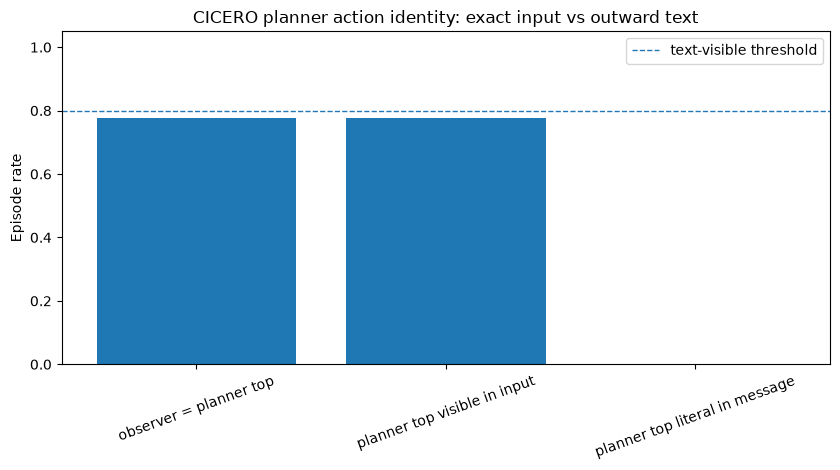

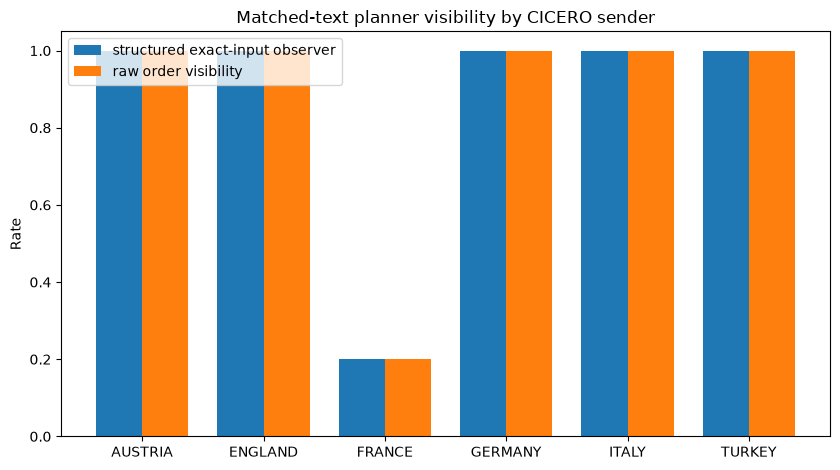

In [12]:
import matplotlib.pyplot as plt

if len(primary):
    labels = [
        "observer = planner top",
        "planner top visible in input",
        "planner top literal in message",
    ]
    values = [observer_exact_rate, raw_visibility_rate, literal_message_rate]
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.bar(labels, values)
    ax.axhline(TEXT_VISIBLE_THRESHOLD, linestyle="--", linewidth=1, label="text-visible threshold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Episode rate")
    ax.set_title("CICERO planner action identity: exact input vs outward text")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "planner_action_text_visibility.png", dpi=180)
    plt.show()

    by_sender = (
        primary.groupby("sender", as_index=False)
        .agg(
            episodes=("sender", "size"),
            observer_exact_rate=("observer_exact_planner_top_match", "mean"),
            raw_visibility_rate=("planner_top_all_orders_visible_anywhere_in_input", "mean"),
        )
        .sort_values("sender")
    )
    by_sender.to_csv(TABLE_DIR / "visibility_by_sender.csv", index=False)
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    x = np.arange(len(by_sender))
    width = 0.38
    ax.bar(x - width / 2, by_sender["observer_exact_rate"], width, label="structured exact-input observer")
    ax.bar(x + width / 2, by_sender["raw_visibility_rate"], width, label="raw order visibility")
    ax.set_xticks(x)
    ax.set_xticklabels(by_sender["sender"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Rate")
    ax.set_title("Matched-text planner visibility by CICERO sender")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "planner_visibility_by_sender.png", dpi=180)
    plt.show()


## 12. Error audit and readiness / stop-go decision

Notebook 17 distinguishes genuine runtime errors from a `KeyboardInterrupt` caused by its own post-target SIGINT. The exemption is narrow: the error event must contain `KeyboardInterrupt`, the notebook must already have reached its capture target, and the error timestamp must be at or after the recorded signal time (with a small clock tolerance).

The branch decision is predeclared:

- if exact observer/planner agreement is at least the visibility threshold, **planner action identity is text-visible** and no stronger observer is needed to refute a privileged-action-identity interpretation;
- if raw order visibility is high but parsing does not match, preserve a formatter/parser mismatch rather than claiming privilege;
- only if both direct measures are below threshold is the branch eligible for a later stronger learned/generative text observer.


In [13]:
stop_signal_time = launch_result.get("stop_metadata", {}).get("signal_sent_time_unix")

def error_text(event):
    payload = event.get("payload") or {}
    return str(payload.get("error", "")) + "\n" + str(payload.get("traceback", ""))

def expected_post_capture_interrupt(event):
    if "KeyboardInterrupt" not in error_text(event):
        return False
    if not launch_result.get("capture_complete"):
        return False
    if stop_signal_time is None:
        return False
    return float(event.get("time_unix", 0.0)) >= float(stop_signal_time) - 0.25

expected_shutdown_interrupts = [e for e in error_events if expected_post_capture_interrupt(e)]
fatal_errors = [e for e in error_events if not expected_post_capture_interrupt(e)]

error_audit = {
    "total_error_events": len(error_events),
    "expected_post_capture_shutdown_interrupts": len(expected_shutdown_interrupts),
    "fatal_error_events": len(fatal_errors),
    "fatal_errors": [
        {
            "event": e.get("event"),
            "sequence": e.get("sequence"),
            "time_unix": e.get("time_unix"),
            "payload": e.get("payload"),
        }
        for e in fatal_errors
    ],
}
(TABLE_DIR / "error_audit.json").write_text(json.dumps(error_audit, indent=2))

primary_count = int(len(primary))
distinct_senders = int(primary["sender"].nunique()) if len(primary) else 0
distinct_recipients = int(primary["recipient"].nunique()) if len(primary) else 0
task_match_rate = fraction_true(episode_df["task_exact_match"]) if len(episode_df) else 0.0

capture_valid = all([
    actual_commit_value == CICERO_COMMIT,
    nb16_readiness.get("ready_for_notebook17_exact_dialogue_observer") is True,
    preflight_probe["returncode"] == 0,
    instrument_probe["returncode"] == 0,
    launch_result.get("capture_complete") is True,
    output_match_rate >= PRIMARY_OUTPUT_MATCH_THRESHOLD,
    planner_pair_rate >= 0.80,
    parse_rate >= 0.80,
    task_match_rate >= 0.95,
    primary_count >= min(TARGET_MESSAGE_EPISODES, 12),
    distinct_senders >= 3,
    distinct_recipients >= 3,
    future_output_leak_rate <= 0.05,
    len(fatal_errors) == 0,
])

text_visible = bool(observer_exact_rate >= TEXT_VISIBLE_THRESHOLD)
raw_visible = bool(raw_visibility_rate >= TEXT_VISIBLE_THRESHOLD)

readiness = {
    "frozen_cicero_commit": actual_commit_value == CICERO_COMMIT,
    "accepted_notebook16_handoff": nb16_readiness.get("ready_for_notebook17_exact_dialogue_observer") is True,
    "notebook16_fatal_errors_absent": nb16_readiness.get("fatal_capture_error_events_absent") is True,
    "legacy_runtime_preflight_pass": preflight_probe["returncode"] == 0,
    "instrumentation_probe_pass": instrument_probe["returncode"] == 0,
    "capture_target_reached": launch_result.get("capture_complete") is True,
    "dialogue_model_output_match_rate_at_least_threshold": output_match_rate >= PRIMARY_OUTPUT_MATCH_THRESHOLD,
    "planner_pair_rate_at_least_0_8": planner_pair_rate >= 0.80,
    "pseudoorder_parse_rate_at_least_0_8": parse_rate >= 0.80,
    "generative_dialogue_task_exact_match_rate_at_least_0_95": task_match_rate >= 0.95,
    "primary_evaluable_episode_count_sufficient": primary_count >= min(TARGET_MESSAGE_EPISODES, 12),
    "primary_distinct_senders_at_least_3": distinct_senders >= 3,
    "primary_distinct_recipients_at_least_3": distinct_recipients >= 3,
    "future_output_leak_rate_at_most_0_05": future_output_leak_rate <= 0.05,
    "fatal_capture_error_events_absent": len(fatal_errors) == 0,
    "capture_valid": capture_valid,
    "planner_action_identity_text_visible": bool(capture_valid and text_visible),
    "planner_orders_raw_text_visible": bool(capture_valid and raw_visible),
    "cicero_planner_action_privileged_access_claim_supported": False,
    "ready_for_notebook18_strong_text_observer": bool(capture_valid and not text_visible and not raw_visible),
    "cicero_mechanistic_text_visibility_branch_complete": bool(capture_valid and (text_visible or raw_visible)),
}

if not capture_valid:
    readiness["decision"] = "capture_or_pairing_invalid_fix_measurement_before_interpretation"
elif text_visible:
    readiness["decision"] = "close_privileged_action_identity_branch_target_is_explicit_in_exact_dialogue_input"
elif raw_visible:
    readiness["decision"] = "do_not_claim_privilege_target_tokens_are_text_visible_debug_formatter_equivalence_only"
else:
    readiness["decision"] = "direct_text_visibility_not_established_stronger_matched_observer_is_allowed"

(TABLE_DIR / "readiness.json").write_text(json.dumps(readiness, indent=2))
print(json.dumps(error_audit, indent=2))
print(json.dumps(readiness, indent=2))

if STRICT_READINESS and not readiness["capture_valid"]:
    raise RuntimeError(
        "Notebook 17 failed one or more exact-input measurement-validity gates. "
        f"Inspect {TABLE_DIR / 'readiness.json'}, {TABLE_DIR / 'visibility_summary.json'}, "
        f"and {TABLE_DIR / 'error_audit.json'}."
    )


{
  "total_error_events": 0,
  "expected_post_capture_shutdown_interrupts": 0,
  "fatal_error_events": 0,
  "fatal_errors": []
}
{
  "frozen_cicero_commit": true,
  "accepted_notebook16_handoff": true,
  "notebook16_fatal_errors_absent": true,
  "legacy_runtime_preflight_pass": true,
  "instrumentation_probe_pass": true,
  "capture_target_reached": true,
  "dialogue_model_output_match_rate_at_least_threshold": true,
  "planner_pair_rate_at_least_0_8": true,
  "pseudoorder_parse_rate_at_least_0_8": true,
  "generative_dialogue_task_exact_match_rate_at_least_0_95": true,
  "primary_evaluable_episode_count_sufficient": true,
  "primary_distinct_senders_at_least_3": true,
  "primary_distinct_recipients_at_least_3": true,
  "future_output_leak_rate_at_most_0_05": true,
  "fatal_capture_error_events_absent": true,
  "capture_valid": true,
  "planner_action_identity_text_visible": false,
  "planner_orders_raw_text_visible": false,
  "cicero_planner_action_privileged_access_claim_supported": f

## 13. Freeze summary, checksums, and archive

The summary preserves the distinction between:

- **planner mechanistic validity** (already established by Notebook 16);
- **planner action identity visibility in the exact dialogue input** (this notebook);
- the project's original **neural activation vs matched-text H1**, which this CICERO mechanistic calibration does not estimate.


In [14]:
def sha256_file(path):
    h = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "cicero_commit": CICERO_COMMIT,
    "source_notebook16_run_id": NB16_RUN_ID,
    "expected_dialogue_task": EXPECTED_DIALOGUE_TASK,
    "purpose": (
        "Capture the exact released CICERO generative dialogue-model input and test whether the paired planner top action is already text-visible through pseudo-orders."
    ),
    "primary_reference": "paired BQRE bilateral get_agent_policy top action for the message sender",
    "matched_text_observer": (
        "deterministic extraction of the sender current-phase pseudo-order block from the exact dialogue-model input sequence"
    ),
    "scientific_status": (
        "Mechanistic matched-information calibration only; not the original activation-vs-text H1 and no causal steering claim."
    ),
    "visibility_summary": visibility_summary,
    "readiness": readiness,
    "error_audit": error_audit,
    "claim_guardrail": (
        "A high observer/planner match means planner action identity is already exposed to the dialogue model as text. "
        "It does not imply that planner probabilities, beliefs, utilities, or all strategic computation are text-visible."
    ),
}
(TABLE_DIR / "result_summary.json").write_text(json.dumps(result_summary, indent=2))

artifact_paths = sorted(
    p for p in RUN_DIR.rglob("*")
    if p.is_file() and p.name != "checksums.json"
)
checksums = [
    {
        "relative_path": str(p.relative_to(RUN_DIR)),
        "sha256": sha256_file(p),
        "size_bytes": p.stat().st_size,
    }
    for p in artifact_paths
]
(RUN_DIR / "checksums.json").write_text(json.dumps(checksums, indent=2))

manifest = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_DIR),
    "source_notebook16_run": str(NB16_RUN_DIR),
    "instrumentation_source": str(INSTRUMENT_DIR / "sitecustomize.py"),
    "exact_input_dir": str(EXACT_INPUT_DIR),
    "episode_table": str(TABLE_DIR / "exact_dialogue_visibility_episodes.csv"),
    "result_summary": str(TABLE_DIR / "result_summary.json"),
    "readiness": str(TABLE_DIR / "readiness.json"),
    "figures": sorted(str(p) for p in FIGURE_DIR.glob("*.png")),
}
(MANIFEST_DIR / "notebook17_manifest.json").write_text(json.dumps(manifest, indent=2))

archive_base = PROJECT_ROOT / f"17_cicero_exact_dialogue_input_visibility_{RUN_ID}"
archive_path = shutil.make_archive(str(archive_base), "zip", root_dir=BASE, base_dir=RUN_ID)

print(json.dumps(result_summary, indent=2))
print()
print("Notebook 17 complete.")
print(f"Result summary: {TABLE_DIR / 'result_summary.json'}")
print(f"Run directory: {RUN_DIR}")
print(f"Archive: {archive_path}")


{
  "notebook_build": "latent-reservations-notebook17-cicero-exact-dialogue-visibility-v1",
  "run_id": "20260815T154340Z",
  "cicero_commit": "e85afeddb34f5b7c1ea0827203b425a0f7e68ead",
  "source_notebook16_run_id": "20260815T143203Z",
  "expected_dialogue_task": "message_history_orderhistorysincelastmovementphase_shortstate_pseudoorder_dialogue_chunk",
  "purpose": "Capture the exact released CICERO generative dialogue-model input and test whether the paired planner top action is already text-visible through pseudo-orders.",
  "primary_reference": "paired BQRE bilateral get_agent_policy top action for the message sender",
  "matched_text_observer": "deterministic extraction of the sender current-phase pseudo-order block from the exact dialogue-model input sequence",
  "scientific_status": "Mechanistic matched-information calibration only; not the original activation-vs-text H1 and no causal steering claim.",
  "visibility_summary": {
    "captured_message_episode_count": 21,
    "pri